In [55]:
import pandas as pd

In [56]:
train_data_path = 'train_data.csv'
train_label_path = 'train_labels.csv'
train_data_path_local = '/media/ub/sec/train_data.csv'
train_label_path_local = '/media/ub/sec/train_labels.csv'

In [57]:
train_label = pd.read_csv(train_label_path_local)

In [58]:
train_label.head(2)

,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0


In [60]:
# train_data = [elem for elem in pd.read_csv(train_data_path_local,chunksize=200000)][0]

In [61]:
# df = train_data.merge(train_label, on='customer_ID', how='inner')

In [62]:
# df.to_csv('amex_data.csv')

In [63]:
df = pd.read_csv('amex_data.csv',index_col=0)

In [64]:
df.shape

(200000, 191)

In [65]:
df.columns

Index(['customer_ID', 'S_2', 'P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41',
       'B_3',
       ...
       'D_137', 'D_138', 'D_139', 'D_140', 'D_141', 'D_142', 'D_143', 'D_144',
       'D_145', 'target'],
      dtype='object', length=191)

In [42]:
categoric_feat = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_68']
numeric_feat = [feat for feat in df.columns if feat not in categoric_feat and feat not in ['customer_ID','target']]
numeric_feat.extend(['customer_ID'])
categoric_feat.extend(['customer_ID'])
target = 'target'

In [43]:
agg_numeric_df = df[numeric_feat].groupby(['customer_ID']).mean()
agg_categoric_df = df[categoric_feat].groupby(['customer_ID']).agg(pd.Series.mode)
agg_target_df = df[[target,'customer_ID']].groupby(['customer_ID']).mean()

In [44]:
X = pd.merge(pd.merge(agg_numeric_df,agg_categoric_df,on='customer_ID'),agg_target_df,on='customer_ID')

In [45]:
numeric_feat

['S_2',
 'P_2',
 'D_39',
 'B_1',
 'B_2',
 'R_1',
 'S_3',
 'D_41',
 'B_3',
 'D_42',
 'D_43',
 'D_44',
 'B_4',
 'D_45',
 'B_5',
 'R_2',
 'D_46',
 'D_47',
 'D_48',
 'D_49',
 'B_6',
 'B_7',
 'B_8',
 'D_50',
 'D_51',
 'B_9',
 'R_3',
 'D_52',
 'P_3',
 'B_10',
 'D_53',
 'S_5',
 'B_11',
 'S_6',
 'D_54',
 'R_4',
 'S_7',
 'B_12',
 'S_8',
 'D_55',
 'D_56',
 'B_13',
 'R_5',
 'D_58',
 'S_9',
 'B_14',
 'D_59',
 'D_60',
 'D_61',
 'B_15',
 'S_11',
 'D_62',
 'D_65',
 'B_16',
 'B_17',
 'B_18',
 'B_19',
 'D_66',
 'B_20',
 'S_12',
 'R_6',
 'S_13',
 'B_21',
 'D_69',
 'B_22',
 'D_70',
 'D_71',
 'D_72',
 'S_15',
 'B_23',
 'D_73',
 'P_4',
 'D_74',
 'D_75',
 'D_76',
 'B_24',
 'R_7',
 'D_77',
 'B_25',
 'B_26',
 'D_78',
 'D_79',
 'R_8',
 'R_9',
 'S_16',
 'D_80',
 'R_10',
 'R_11',
 'B_27',
 'D_81',
 'D_82',
 'S_17',
 'R_12',
 'B_28',
 'R_13',
 'D_83',
 'R_14',
 'R_15',
 'D_84',
 'R_16',
 'B_29',
 'S_18',
 'D_86',
 'D_87',
 'R_17',
 'R_18',
 'D_88',
 'B_31',
 'S_19',
 'R_19',
 'B_32',
 'S_20',
 'R_20',
 'R_21',
 '

In [26]:
X

,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,...,B_30,B_38,D_114,D_116,D_117,D_120,D_126,D_63,D_64,D_68
customer_ID,,,,,,,,,,,,,,,,,,,,,
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fbac11a8ed792feb62a,0.933824,0.010704,0.012007,1.005086,0.004509,0.113215,0.005021,0.006456,NaN,NaN,...,0.0,2.0,1.0,0.0,4.0,0.0,1.0,CR,O,6.0
00000fd6641609c6ece5454664794f0340ad84dddce9a267a310b5ae68e9d8e5,0.899820,0.215205,0.025654,0.991083,0.006246,0.120578,0.004993,0.005663,NaN,0.144571,...,0.0,2.0,1.0,0.0,-1.0,0.0,1.0,CO,O,6.0
00001b22f846c82c51f6e3958ccd81970162bae8b007e80662ef27519fcc18c1,0.878454,0.004181,0.004386,0.815677,0.006621,NaN,0.006842,0.005493,NaN,NaN,...,0.0,1.0,1.0,0.0,-1.0,0.0,1.0,CO,R,6.0
000041bdba6ecadd89a52d11886e8eaaec9325906c9723355abb5ca523658edc,0.598969,0.048862,0.059876,0.955264,0.005665,0.247750,0.005490,0.006423,NaN,0.061026,...,0.0,2.0,1.0,0.0,6.0,0.0,1.0,CO,O,3.0
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad51ca8b8c4a24cefed,0.891679,0.004644,0.005941,0.814543,0.004180,0.173102,0.005352,0.005088,NaN,0.048778,...,0.0,1.0,1.0,0.0,4.0,0.0,1.0,CO,O,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0956f2eafc5d8919835f76f6e40835b49900cf91c3de18c3c80da1ae33fb06eb,0.678326,0.156436,0.028466,0.862304,0.081804,0.258664,0.018045,0.020276,NaN,0.019518,...,0.0,2.0,1.0,0.0,4.0,0.0,1.0,CR,O,6.0
0956f6dbb2671e10a40180b39ea793fb73633767ef70be12f3946a08b46b6c99,0.878564,0.004776,0.024717,0.845940,0.023578,0.190138,0.005640,0.005897,NaN,0.353553,...,0.0,1.0,0.0,0.0,4.0,0.0,1.0,CO,O,6.0
095700a5c40952f9c134c6a71700bbd959098adfdcf2c7330351d9468f8b33a7,0.658187,0.186741,0.029593,1.004047,0.043588,0.092357,0.005135,0.006966,NaN,0.098592,...,0.0,2.0,1.0,0.0,3.0,0.0,1.0,CO,R,6.0


<AxesSubplot:>

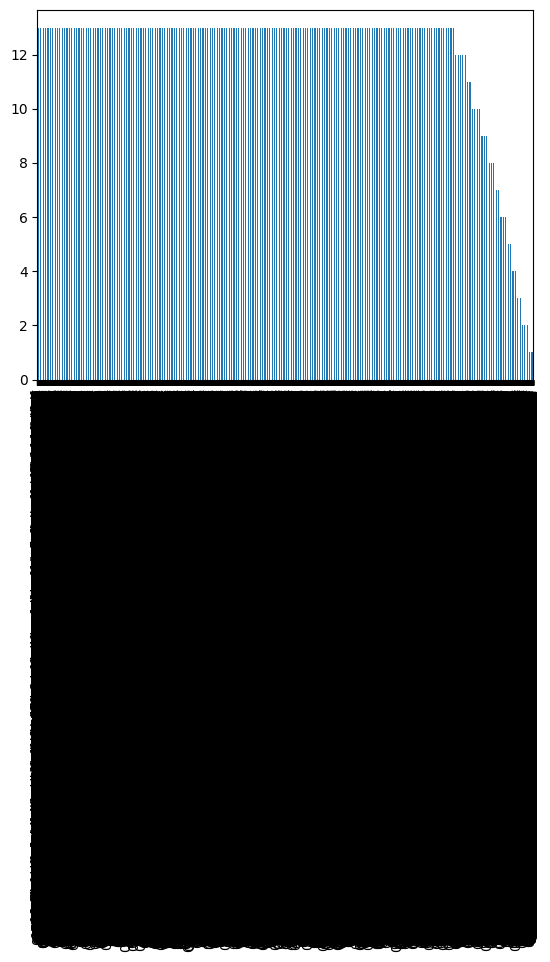

In [27]:
X['customer_ID'].value_counts().plot(kind='bar')

In [15]:
X['target'].value_counts()

0    149321
1     50679
Name: target, dtype: int64

<AxesSubplot:>

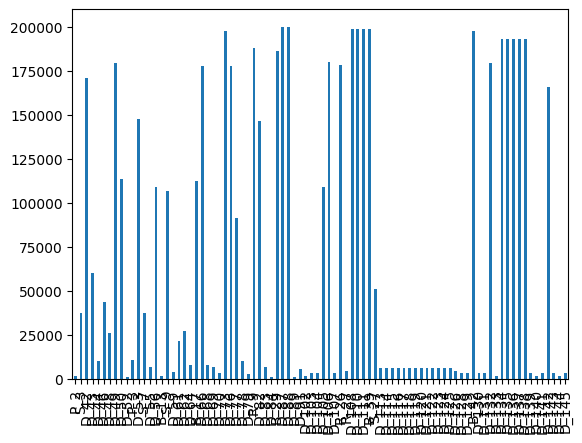

In [26]:
X.isnull().sum()[X.isnull().sum() > 1000].plot(kind='bar')